In this notebook, we will develop models to predict whether a given car gets high or low gas mileage based on the `Auto` data set containing $392$ observations.

We first create a binary variable, `mpg01`, that contains a $1$ if `mpg` contains a value above its median, and a $0$ if `mpg` contains a value below its median. We can compute the median using the `median()` method.

In [1]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS)

import numpy as np
import pandas as pd

Auto = load_data('Auto')

In [2]:
median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > median).astype(int)
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0


Now, we will explore the data graphically in order to investigate the association between `mpg01` and the other features. An easy way to do this is to plot a scatter matrix of the variables.

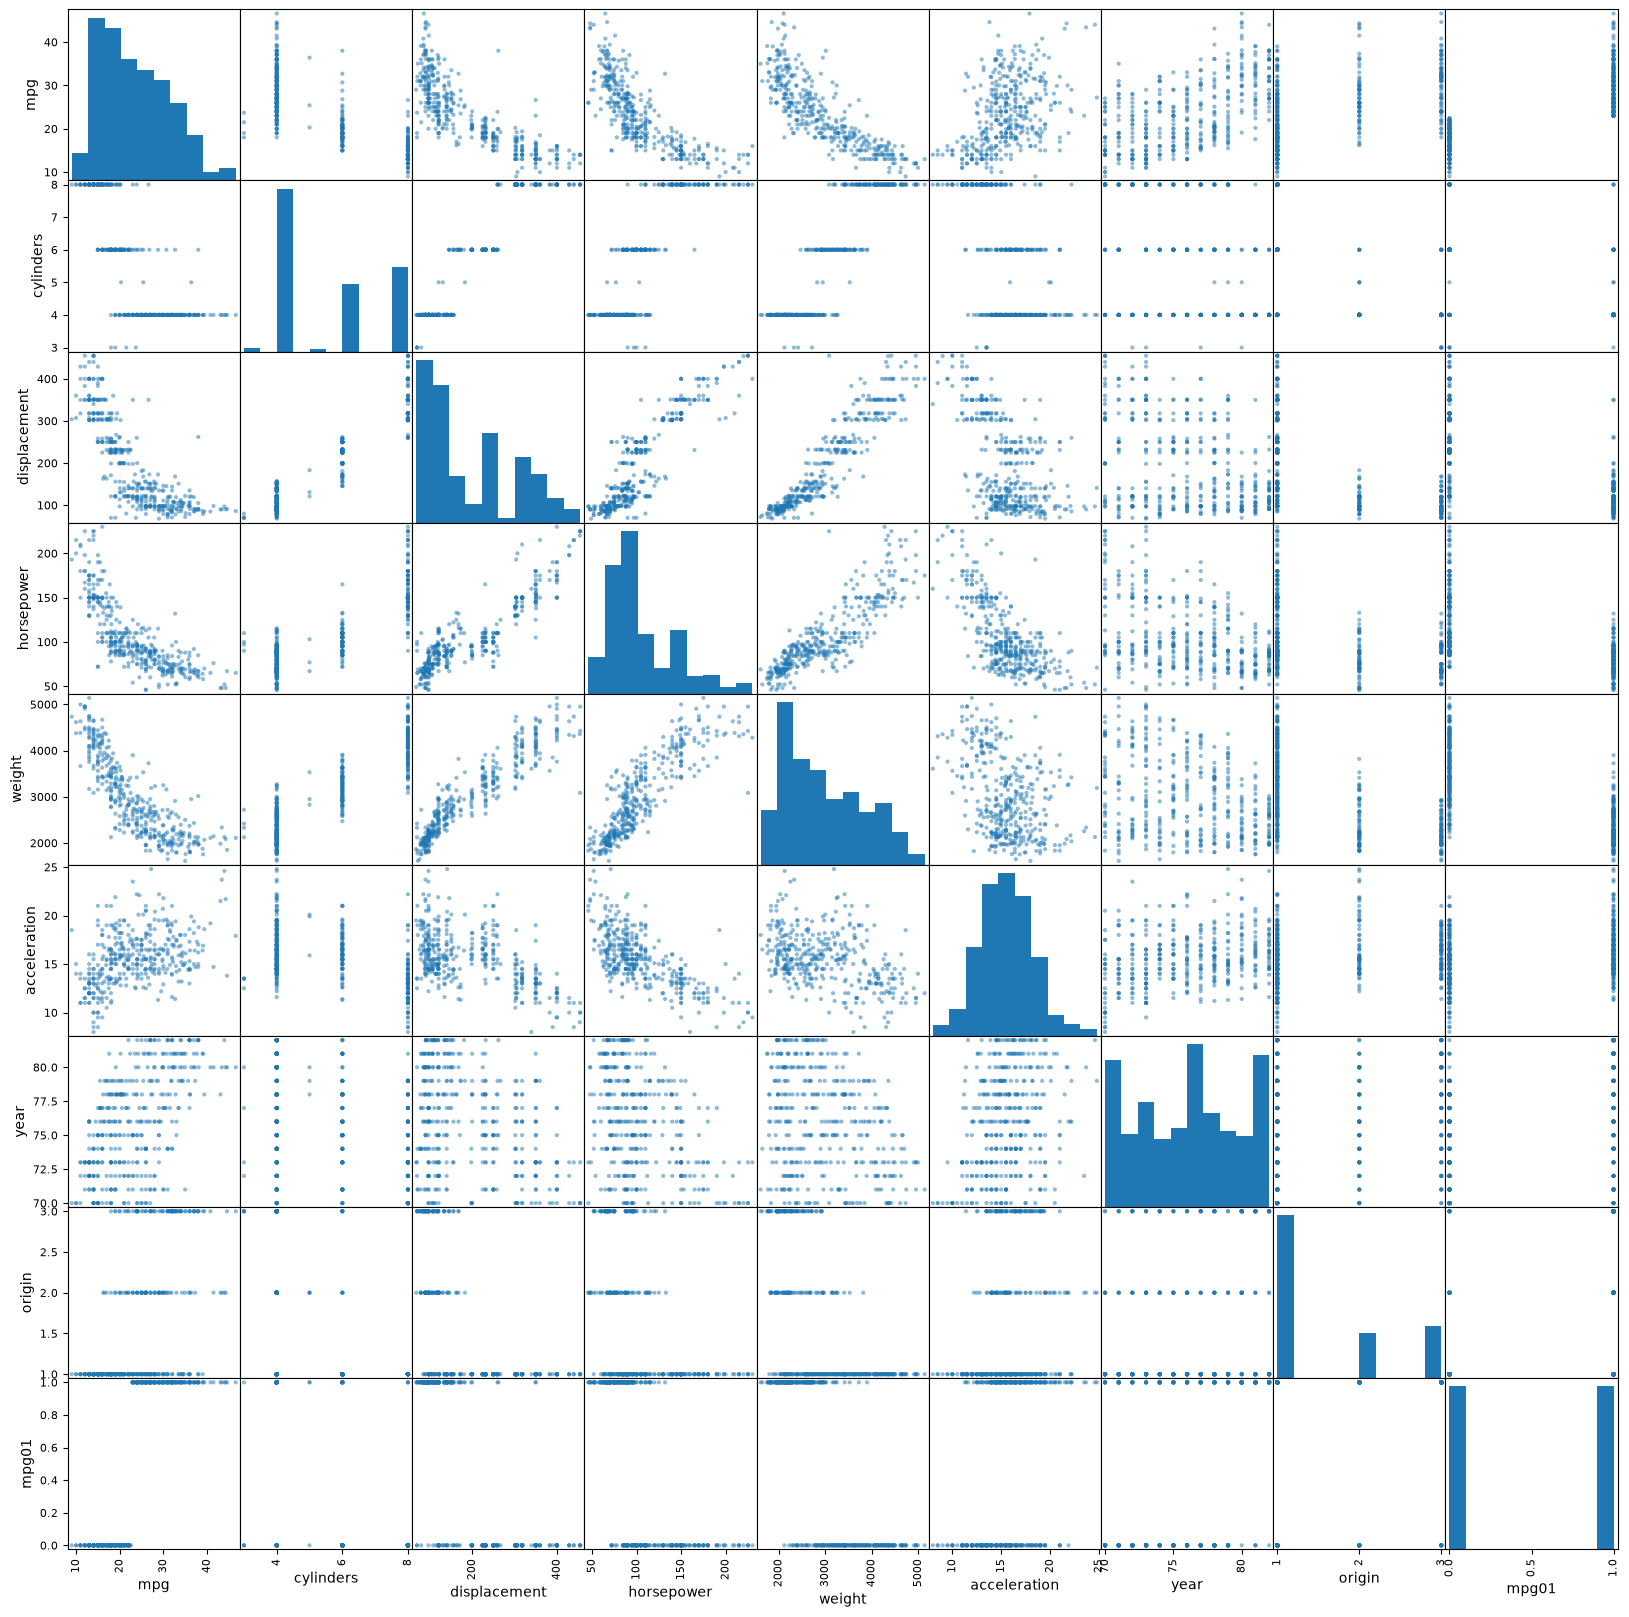

In [3]:
pd.plotting.scatter_matrix(Auto, figsize=(20,20));

Focussing on the bottom-most row, `mpg01` seems to be $1$ when
* `horsepower` is low
* `weight` is low
* `acceleration` is high

It is time to get ready to train some models. Here we split the data into a training set and a test set.

In [4]:
train = Auto.iloc[:-100]
test = Auto.iloc[-100:]

We perform LDA on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in the scatter matrix plot.

In [5]:
X_train = MS(['horsepower', 'weight', 'acceleration'], intercept=False).fit_transform(train)
y_train = train['mpg01']

X_test = MS(['horsepower', 'weight', 'acceleration'], intercept=False).fit_transform(test)
y_test = test['mpg01']

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix

lda_model = LDA(store_covariance=True).fit(X_train, y_train)
print(f'Classes:\n{lda_model.classes_}')
print(f'Priors:\n{lda_model.priors_}')
print(f'Means:\n{lda_model.means_}')
print(f'Covariance:\n{lda_model.covariance_}')


Classes:
[0 1]
Priors:
[0.65410959 0.34589041]
Means:
[[ 130.97905759 3630.59162304   14.53350785]
 [  77.8019802  2221.34653465   16.43465347]]
Covariance:
[[ 9.88582041e+02  1.38850079e+04 -5.71033318e+01]
 [ 1.38850079e+04  3.34353161e+05 -5.66084587e+02]
 [-5.71033318e+01 -5.66084587e+02  6.40374747e+00]]


To see how accurate our model is, we output the confusion matrix for the predictions made by the fitted LDA model on the test data, and calculate the test error rate.

The confusion matrix is a $2\times 2$ matrix that displays the number of true/false positive/negatives predicted by our model. An index of `0` denotes negative results, and an index of `1` denotes positive results. The rows display true positive/negatives and the columns display predicted positive/negatives.

In [6]:
y_pred = lda_model.predict(X_test)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

print(f'Confusion matrix:\n{matrix}')
print(f'Test error rate = {(matrix[0][1]+matrix[1][0])/len(y_pred):.2f}')

Confusion matrix:
[[ 5  0]
 [20 75]]
Test error rate = 0.20


Now we perform QDA on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in the scatter matrix plot. The test error rates are higher now, which indicates that the higher variance as a result of the greater number of parameters of QDA was not adequately compensated by a decrease in bias from a more flexible fit. This could be because of insufficient training data, or because the true covariance matrices for different classes are already similar enough that there is not much bias reduction achieved using QDA over LDA.

In [7]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

qda_model = QDA().fit(X_train, y_train)
y_pred = qda_model.predict(X_test)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

print(f'Confusion matrix:\n{matrix}')
print(f'Test error rate = {(matrix[0][1]+matrix[1][0]) / len(y_pred):.2f}')

Confusion matrix:
[[ 5  0]
 [22 73]]
Test error rate = 0.22


We now perform logistic regression on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01`. There seems to be a great increase in test error rates, which might indicate that the predictors' underlying distribution is close enough to a normal distribution. In this case, LDA does not suffer much model bias, and has lower variance due to it leveraging the assumption of a normal distribution, leading to a better performance by LDA than logistic regression.

In [8]:
import statsmodels.api as sm

X_train_logit = X_train.copy()
X_train_logit['intercept'] = 1

X_test_logit = X_test.copy()
X_test_logit['intercept'] = 1

logistic_model = sm.GLM(y_train, X_train_logit, family=sm.families.Binomial()).fit()
print(logistic_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  mpg01   No. Observations:                  292
Model:                            GLM   Df Residuals:                      288
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -55.482
Date:                Sat, 19 Sep 2026   Deviance:                       110.96
Time:                        22:55:03   Pearson chi2:                     120.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.5974
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
horsepower      -0.0761      0.031     -2.440   

In [9]:
y_pred = (logistic_model.predict(X_test_logit) > 0.5).astype(int)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

print(f'Confusion matrix:\n{matrix}')
print(f'Test error rate = {(matrix[0][1] + matrix[1][0]) / len(y_pred)}')

Confusion matrix:
[[ 5  0]
 [31 64]]
Test error rate = 0.31


In [10]:
from sklearn.linear_model import LogisticRegression

sklogit_model = LogisticRegression(C=1e10, solver='liblinear').fit(X_train_logit, y_train)
y_pred = sklogit_model.predict(X_test_logit)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

print(f'Confusion matrix:\n{matrix}')
print(f'Test error rate = {(matrix[0][1]+matrix[1][0]) / len(y_pred)}')

Confusion matrix:
[[ 5  0]
 [35 60]]
Test error rate = 0.35


Perform naive Bayes on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in part (b). What is the test error of the model obtained?

In [11]:
from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB().fit(X_train, y_train)
y_pred = naive_bayes_model.predict(X_test)
matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)

print(f'Confusion matrix:\n{matrix}')
print(f'Test error rate = {(matrix[0][1]+matrix[1][0]) / len(y_pred)}')

Confusion matrix:
[[ 5  0]
 [19 76]]
Test error rate = 0.19


Finally, we try perform K-Nearest Neighbours on the training data, with several values of $K$, in order to predict `mpg01`. We plot the test error rates for different values of $K$.

Text(0.5, 0, 'K')

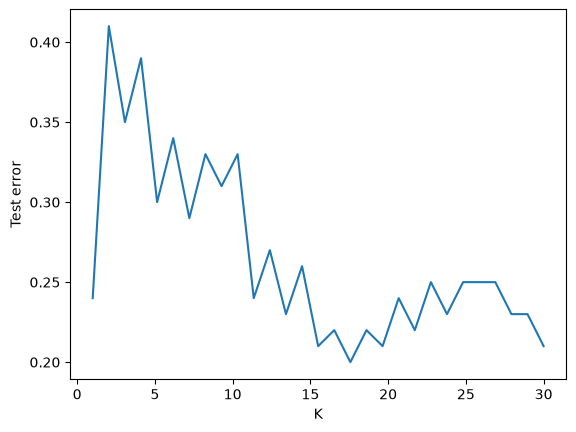

In [12]:
def test_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
    error = (matrix[0][1] + matrix[1][0]) / len(y_pred)
    return error

from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

errors = [test_model(KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train), X_test, y_test) for k in range(1,30)]
plt.plot(np.linspace(1,30,29), errors)
plt.ylabel('Test error')
plt.xlabel('K')

The value of $K$ that performs the best seems to be $K=17$, with a test error rate of $0.20$.